In [1]:
#Basic libraries
import numpy as np
import pandas as pd

#Visualization Libraries
import matplotlib.pyplot as plt
import pydot
import seaborn as sns

#Evaluation Libraries
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

#Deep Learning Libraries
import tensorflow as tf
from tensorflow.keras import layers
import keras
from keras.models import Sequential
from keras.layers import Dense, Activation, Dropout, Flatten
# from keras.layers.core import Dense,Activation,Dropout
from keras.datasets import mnist
from keras import utils as np_utils
from keras.utils import to_categorical
from scikeras.wrappers import KerasClassifier
# from keras.wrappers.scikit_learn import KerasClassifier


In [2]:
#Load digitmnist dataset
(X_train_digit,y_train_digit),(X_test_digit,y_test_digit) = mnist.load_data()

In [3]:
X_train_digit

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

In [7]:
X_train_digit[1].shape

(28, 28)

In [5]:
y_train_digit

array([5, 0, 4, ..., 5, 6, 8], shape=(60000,), dtype=uint8)

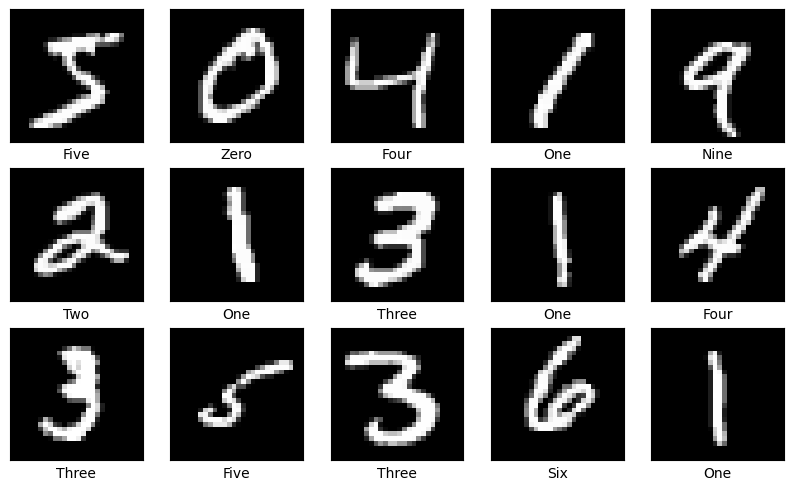

In [8]:
col_names = ['Zero','One','Two','Three','Four','Five','Six','Seven','Eight','Nine']

#visulaize the digits
plt.figure(figsize=(10,10))
for i in range(15):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(X_train_digit[i],cmap ='gray')
    plt.xlabel(col_names[y_train_digit[i]])
plt.show()

In [9]:
X_train_digit.shape

(60000, 28, 28)

In [10]:
X_test_digit.shape

(10000, 28, 28)

In [11]:
#Preprocess the input - convert the 3D image to 2D for ANN.
X_train_digit = X_train_digit.reshape(60000,784) #flatterning the rows and columns of the matrix
X_test_digit = X_test_digit.reshape(10000,784)

In [12]:
X_train_digit

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(60000, 784), dtype=uint8)

In [13]:
X_train_digit[59999][783]

np.uint8(0)

In [14]:
y_train_digit.shape

(60000,)

In [15]:
y_train_digit

array([5, 0, 4, ..., 5, 6, 8], shape=(60000,), dtype=uint8)

In [16]:
#Preprocess the output
y_test_digit

array([7, 2, 1, ..., 4, 5, 6], shape=(10000,), dtype=uint8)

In [17]:
#convert the oneD to categorial - Encoding digit mnist labels - output should be One hot encoding for ANN
y_train_digit = to_categorical(y_train_digit,num_classes = 10)
y_test_digit = to_categorical(y_test_digit,num_classes = 10)

In [18]:
y_train_digit

array([[0., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.]], shape=(60000, 10))

In [19]:
y_test_digit

array([[0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(10000, 10))

In [20]:
#ANN and CNN are sequential process I/P - hiden layer - O/P
# Feedforward
model = keras.Sequential([
    layers.Dense(256,activation = 'relu',input_shape=(784,),), #Input layer
    # layers.Dropout(0.3),
    # layers.BatchNormalization(),
    layers.Dense(64,activation = 'relu'), # first hidden layer
    # layers.Dropout(0.3),
    # layers.BatchNormalization(),
    layers.Dense(64,activation = 'relu'), # second hidden layer
    # layers.Dropout(0.3),
    # layers.BatchNormalization(),
    layers.Dense(10,activation = 'sigmoid'),# output layer - one to 10 categories
])

C:\Users\SAIRAM\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [21]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 256)                 │         200,960 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │          16,448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 222,218 (868.04 KB)

 Trainable params: 222,218 (868.04 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
#compiling the model - https://keras.io/api/
model.compile(loss = "categorical_crossentropy",
            optimizer = "adam",
             metrics=['accuracy'])

In [23]:
history = model.fit(X_train_digit,y_train_digit,batch_size = 100,epochs = 10,validation_data = (X_test_digit,y_test_digit) )

Epoch 1/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.6335 - loss: 1.5703 - val_accuracy: 0.7330 - val_loss: 0.3899
Epoch 2/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7663 - loss: 0.2672 - val_accuracy: 0.7640 - val_loss: 0.2668
Epoch 3/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7333 - loss: 0.1885 - val_accuracy: 0.7435 - val_loss: 0.2269
Epoch 4/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7259 - loss: 0.1481 - val_accuracy: 0.6663 - val_loss: 0.2097
Epoch 5/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7113 - loss: 0.1248 - val_accuracy: 0.6689 - val_loss: 0.2115
Epoch 6/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6844 - loss: 0.1103 - val_accuracy: 0.6866 - val_loss: 0.1804
Epoch 7/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6756 - loss: 0.1043 - val_accuracy: 0.7364 - val_loss: 0.1846
Epoch 8/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6577 - loss: 0.1052 - val_accuracy: 0.

In [24]:
#to test
y_predict = model.predict(X_test_digit)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [25]:
y_predict

array([[8.0418205e-01, 4.5130029e-01, 9.9845558e-01, ..., 1.0000000e+00,
        9.9840015e-01, 9.9997813e-01],
       [9.9805123e-01, 1.0000000e+00, 1.0000000e+00, ..., 9.9999994e-01,
        1.0000000e+00, 2.1164592e-01],
       [2.6596218e-02, 1.0000000e+00, 8.9569807e-01, ..., 9.9965829e-01,
        9.4579959e-01, 1.3250112e-02],
       ...,
       [3.0391005e-01, 1.0000000e+00, 9.6434617e-01, ..., 1.0000000e+00,
        1.0000000e+00, 1.0000000e+00],
       [3.1611060e-09, 2.1798421e-06, 2.1065611e-03, ..., 1.1691494e-03,
        1.0000000e+00, 5.9267093e-04],
       [1.0000000e+00, 6.2319499e-01, 3.1435227e-01, ..., 8.3731786e-09,
        1.0000000e+00, 4.9752784e-06]], shape=(10000, 10), dtype=float32)

In [26]:
#predicted data
y_predicts = np.argmax(y_predict,axis = 1)

In [27]:
y_predicts

array([7, 1, 1, ..., 1, 5, 0], shape=(10000,))

In [28]:
#actual data
y_test_digit_eval = np.argmax(y_test_digit,axis=1)

In [29]:
y_test_digit_eval

array([7, 2, 1, ..., 4, 5, 6], shape=(10000,))

[[ 965    0    0    1    0    2    5    1    4    2]
 [   0 1130    0    0    0    1    2    0    1    1]
 [  80  154  760   10    2    3    3    6   14    0]
 [   2  722   22  244    0    6    0    1    4    9]
 [   1  639    1   11  297    0    4    1    3   25]
 [  16    1    1  323    2  537    5    0    1    6]
 [ 515    6    1    1   36  261  136    0    2    0]
 [   0  205   31  323    1    3    0  442    4   19]
 [   0    6    0    9    1   13    2    4  935    4]
 [   1    4    0    6   10    5    0    6    1  976]]


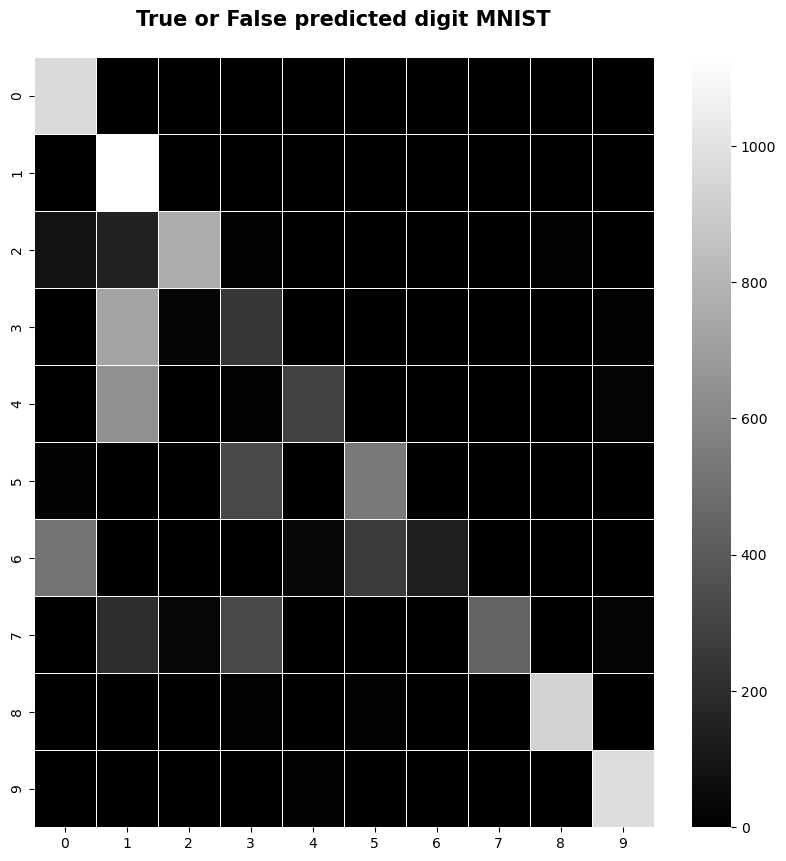

In [30]:
#confusion matrix for Digit Mnist
con_mat = confusion_matrix(y_test_digit_eval,y_predicts)
print(con_mat)
# plt.style.use('seaborn-v0_8-deep')
plt.figure(figsize=(10,10))
sns.heatmap(con_mat,annot_kws={'size':15},linewidth=0.5,fmt ='d',cmap ='grey')
plt.title('True or False predicted digit MNIST\n',fontweight='bold',fontsize=15)
plt.show()


In [31]:
from sklearn.metrics import classification_report
report = classification_report(y_test_digit_eval,y_predicts)

In [32]:
print(report)

              precision    recall  f1-score   support

           0       0.61      0.98      0.75       980
           1       0.39      1.00      0.56      1135
           2       0.93      0.74      0.82      1032
           3       0.26      0.24      0.25      1010
           4       0.85      0.30      0.45       982
           5       0.65      0.60      0.62       892
           6       0.87      0.14      0.24       958
           7       0.96      0.43      0.59      1028
           8       0.96      0.96      0.96       974
           9       0.94      0.97      0.95      1009

    accuracy                           0.64     10000
   macro avg       0.74      0.64      0.62     10000
weighted avg       0.74      0.64      0.62     10000



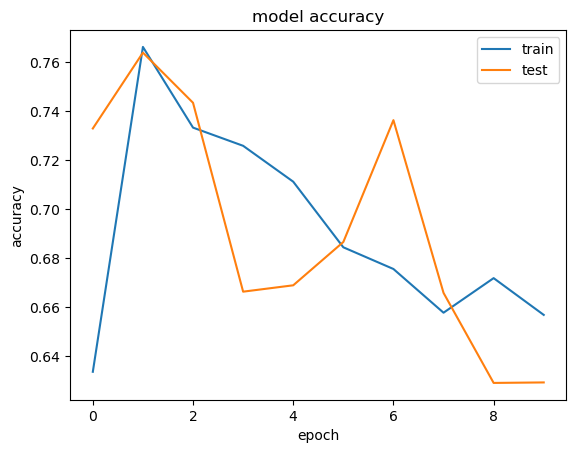

In [33]:
#summarize history for accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train','test'],loc = 'best')
plt.show()

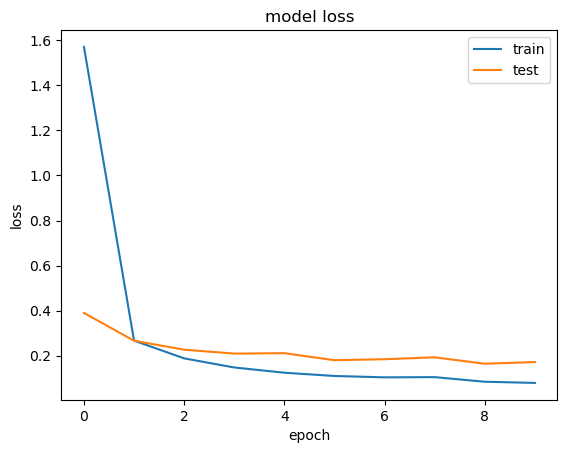

In [34]:
#summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train','test'],loc = 'best')
plt.show()

In [47]:
y_predict_single = model.predict(X_test_digit[[0]])
print(y_predict_single)
y_predicts_single = np.argmax(y_predict_single,axis=1)
print(y_predicts_single)
y_test_digit_eval = np.argmax(y_test_digit,axis =1)
print(y_test_digit_eval[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
[[0.80418235 0.45130014 0.9984556  0.99999976 0.15480922 0.9402053
  0.94404197 1.         0.99840015 0.9999781 ]]
[7]
7


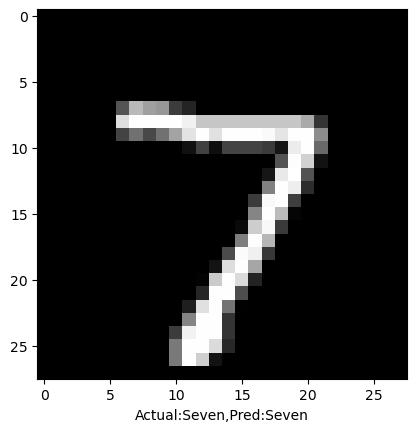

In [49]:
col_names = ['Zero','One','Two','Three','Four','Five','Six','Seven','Eight','Nine']

#visulaize the digits
plt.imshow(X_test_digit[0].reshape(28,28),cmap ='gray')
plt.xlabel("Actual:{},Pred:{}".format(col_names[y_test_digit_eval[0]],col_names[y_predicts_single[0]]))
plt.show()